2025/10/09 12:11:46 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing SVM using PSO...


2025/10/09 12:12:27 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7789016120094331, Global best: -0.7789016120094331, Runtime: 20.32859 seconds
2025/10/09 12:12:48 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 21.61538 seconds
2025/10/09 12:13:49 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 60.77261 seconds
2025/10/09 12:15:18 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 89.20149 seconds
2025/10/09 12:16:31 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 72.78055 seconds
2025/10/09 12:16:31 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: Bas

PSO Accuracy: 0.7857
PSO Best Params: {'C': 2.762, 'gamma': 0.0984, 'kernel': 'rbf'}

Optimizing SVM using GA...


2025/10/09 12:17:14 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 23.95861 seconds
2025/10/09 12:17:31 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 16.95159 seconds
2025/10/09 12:17:51 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 20.40528 seconds
2025/10/09 12:18:17 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 25.90442 seconds
2025/10/09 12:18:49 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7725301117994517, Global best: -0.7775354917908538, Runtime: 32.17135 seconds
2025/10/09 12:18:49 AM, INFO, mealpy.swarm_based.BA.OriginalBA: O

GA Accuracy: 0.7775
GA Best Params: {'C': 2.099, 'gamma': 0.2579, 'kernel': 'rbf'}

Optimizing SVM using Bat...


2025/10/09 12:19:38 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 24.02116 seconds
2025/10/09 12:20:19 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 40.49087 seconds
2025/10/09 12:20:43 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 24.95344 seconds
2025/10/09 12:21:26 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 42.81709 seconds
2025/10/09 12:22:06 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 40.19884 seconds


Bat Accuracy: 0.7725
Bat Best Params: {'C': 1.082, 'gamma': 0.0034, 'kernel': 'linear'}



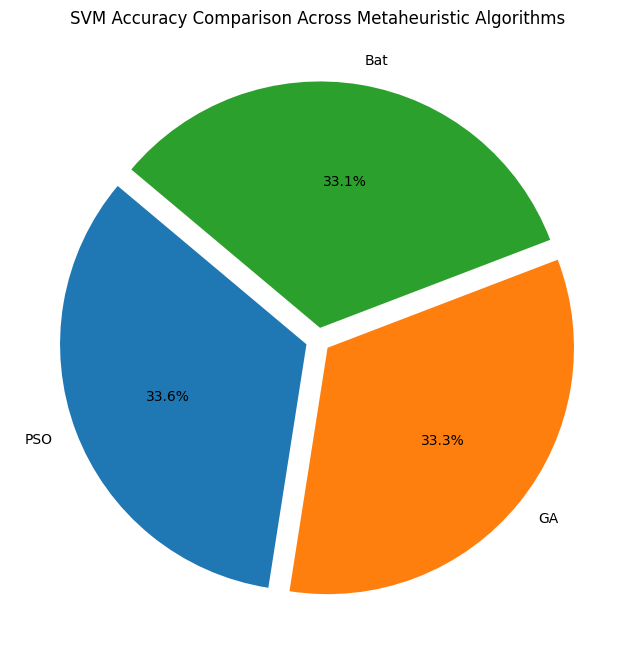

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# SVM Objective Function
# ----------------------------
def svm_objective_function(solution):
    C = solution[0]
    gamma = solution[1]
    kernel_idx = int(solution[2])
    kernels = ['linear', 'rbf', 'poly']
    kernel = kernels[kernel_idx % len(kernels)]  # ensure valid index
    
    try:
        svm = SVC(C=C, gamma=gamma, kernel=kernel, random_state=42)
        scores = cross_val_score(svm, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # minimize negative accuracy
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# SVM Problem Definition
# ----------------------------
svm_problem = {
    "bounds": [
        FloatVar(lb=0.1, ub=10, name="C"),        # Regularization
        FloatVar(lb=0.0001, ub=1, name="gamma"),  # Kernel coefficient
        FloatVar(lb=0, ub=2, name="kernel")       # 0=linear,1=rbf,2=poly
    ],
    "minmax": "min",
    "obj_func": svm_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing SVM using {name}...")
    best_agent = optimizer.solve(svm_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness

    kernel_idx = int(best_solution[2])
    kernels = ['linear', 'rbf', 'poly']
    kernel = kernels[kernel_idx % len(kernels)]

    best_params = {
        'C': round(best_solution[0], 3),
        'gamma': round(best_solution[1], 4),
        'kernel': kernel
    }

    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("SVM Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC

# ----------------------------
# Mealpy imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings("ignore")

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    df = pd.concat([amazon, imdb, yelp], axis=0)

    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# SVM Objective Function
# ----------------------------
def svm_objective_function(solution):
    C = solution[0]
    kernel_idx = int(solution[1])
    gamma = solution[2]

    kernel_options = ['linear', 'poly', 'rbf', 'sigmoid']
    kernel = kernel_options[kernel_idx % len(kernel_options)]  # wrap index safely

    try:
        model = SVC(C=C, kernel=kernel, gamma=gamma, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
        fitness = -np.mean(scores)
    except:
        fitness = 1.0  # penalty for invalid params
    return fitness

# ----------------------------
# Problem Definition
# ----------------------------
svm_problem = {
    "bounds": [
        FloatVar(lb=0.1, ub=10, name="C"),             # Regularization strength
        FloatVar(lb=0, ub=3, name="kernel"),           # 0=linear,1=poly,2=rbf,3=sigmoid
        FloatVar(lb=0.0001, ub=1, name="gamma"),       # Kernel coefficient
    ],
    "minmax": "min",
    "obj_func": svm_objective_function,
}

# ----------------------------
# Metaheuristic Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "BA": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "CSO": CSO.OriginalCSO(epoch=5, pop_size=10),
    "FA": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10),
}

# ----------------------------
# Run Optimization
# ----------------------------
svm_results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing SVM using {name}...")
    best_agent = optimizer.solve(svm_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness

    kernel_options = ['linear', 'poly', 'rbf', 'sigmoid']
    kernel = kernel_options[int(best_solution[1]) % len(kernel_options)]

    best_params = {
        "C": round(best_solution[0], 3),
        "kernel": kernel,
        "gamma": round(best_solution[2], 4),
    }

    svm_results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Bar Chart of Accuracy
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(svm_results.keys(), svm_results.values(), color="coral", alpha=0.8)
plt.title("SVM Accuracy Comparison Across Metaheuristic Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ----------------------------
# Pie Chart of Accuracy
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(
    svm_results.values(),
    labels=svm_results.keys(),
    autopct="%1.1f%%",
    startangle=140,
    explode=[0.05] * len(svm_results),
)
plt.title("SVM Accuracy Distribution (Metaheuristic Algorithms)")
plt.show()


2025/10/09 08:31:49 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing SVM using PSO...


2025/10/09 08:32:58 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.775259867252129, Global best: -0.775259867252129, Runtime: 33.71360 seconds
2025/10/09 08:33:26 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7784456173571196, Global best: -0.7784456173571196, Runtime: 28.07467 seconds
2025/10/09 08:33:57 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7829950026962081, Global best: -0.7829950026962081, Runtime: 31.59020 seconds
2025/10/09 08:34:28 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7829950026962081, Global best: -0.7829950026962081, Runtime: 30.51467 seconds
2025/10/09 08:35:02 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7834509973485216, Global best: -0.7834509973485216, Runtime: 33.84535 seconds
2025/10/09 08:35:02 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseG

PSO Accuracy: 0.7835
PSO Best Params: {'C': 1.388, 'kernel': 'rbf', 'gamma': 0.2571}

Optimizing SVM using GA...


2025/10/09 08:36:06 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7729842427134042, Global best: -0.7729842427134042, Runtime: 31.01302 seconds
2025/10/09 08:36:40 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7729842427134042, Global best: -0.7729842427134042, Runtime: 34.30421 seconds
2025/10/09 08:37:15 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7729842427134042, Global best: -0.7729842427134042, Runtime: 35.22525 seconds
2025/10/09 08:37:52 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7757152406583221, Global best: -0.7757152406583221, Runtime: 36.47553 seconds
2025/10/09 08:38:35 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7757152406583221, Global best: -0.7757152406583221, Runtime: 43.29808 seconds
2025/10/09 08:38:35 AM, INFO, mealpy.swarm_based.BA.OriginalBA: O

...

2025/10/09 08:43:37 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 1, Current best: -0.7798092525912176, Global best: -0.7798092525912176, Runtime: 67.93779 seconds
2025/10/09 08:45:24 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 2, Current best: -0.7798092525912176, Global best: -0.7798092525912176, Runtime: 107.13795 seconds
2025/10/09 08:46:46 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 3, Current best: -0.7798092525912176, Global best: -0.7798092525912176, Runtime: 82.28892 seconds
2025/10/09 08:48:11 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 4, Current best: -0.7839038857702333, Global best: -0.7839038857702333, Runtime: 84.12179 seconds
2025/10/09 08:49:17 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 5, Current best: -0.7839038857702333, Global best: -0.7839038857702333, Runtime: 66.14224 seconds
2025/10/09 08:49:17 AM, INFO, mealpy.swarm_based.CSO.Origin

ACO Accuracy: 0.7839
ACO Best Params: {'C': 0.548, 'kernel': 'linear', 'gamma': 0.7264}

Optimizing SVM using CSO...


2025/10/09 08:56:12 AM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 1, Current best: -0.7829943814500878, Global best: -0.7829943814500878, Runtime: 385.04054 seconds
2025/10/09 09:05:06 AM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 2, Current best: -0.7770813608769013, Global best: -0.7829943814500878, Runtime: 534.33558 seconds
2025/10/09 09:12:53 AM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 3, Current best: -0.7725307330455721, Global best: -0.7829943814500878, Runtime: 466.34862 seconds
2025/10/09 09:19:08 AM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 4, Current best: -0.7852675210043314, Global best: -0.7852675210043314, Runtime: 374.88450 seconds
2025/10/09 09:28:53 AM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 5, Current best: -0.7843598804225467, Global best: -0.7852675210043314, Runtime: 585.88330 seconds
2025/10/09 09:28:53 AM, INFO, mealpy.swarm_based.FA.OriginalFA: O

CSO Accuracy: 0.7853
CSO Best Params: {'C': 0.614, 'kernel': 'linear', 'gamma': 1.0}

Optimizing SVM using FA...


2025/10/09 09:46:25 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7852700059888126, Global best: -0.7852700059888126, Runtime: 992.44902 seconds
2025/10/09 10:02:18 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7852700059888126, Global best: -0.7852700059888126, Runtime: 953.10093 seconds
2025/10/09 10:14:03 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7861776465705971, Global best: -0.7861776465705971, Runtime: 704.50786 seconds


2025/10/09 12:34:28 PM, INFO, mealpy.swarm_based.FA.OriginalFA: OriginalFA(epoch=5, pop_size=10, max_sparks=100, p_a=0.04, p_b=0.8, max_ea=40, m_sparks=100)


Optimizing SVM using FA...


2025/10/09 12:48:37 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7848140113364992, Global best: -0.7848140113364992, Runtime: 825.15479 seconds
2025/10/09 12:54:23 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7852687634965719, Global best: -0.7852687634965719, Runtime: 345.39036 seconds
2025/10/09 01:06:45 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7857216519182838, Global best: -0.7857216519182838, Runtime: 741.79256 seconds
2025/10/09 01:21:54 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.7857216519182838, Global best: -0.7857216519182838, Runtime: 909.56044 seconds
2025/10/09 01:37:18 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.7857216519182838, Global best: -0.7857216519182838, Runtime: 923.29671 seconds
2025/10/09 01:37:18 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalA

FA Accuracy: 0.7857
FA Best Params: {'C': 0.643, 'kernel': 'linear', 'gamma': 0.1558}

Optimizing SVM using ABC...


2025/10/09 01:38:23 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.7679782414758819, Global best: -0.7679782414758819, Runtime: 41.62103 seconds
2025/10/09 01:39:11 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.7752629734827305, Global best: -0.7752629734827305, Runtime: 48.34909 seconds
2025/10/09 01:39:59 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.7811735090714359, Global best: -0.7811735090714359, Runtime: 47.66133 seconds
2025/10/09 01:40:50 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.7811735090714359, Global best: -0.7811735090714359, Runtime: 50.79993 seconds
2025/10/09 01:41:44 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.7811735090714359, Global best: -0.7811735090714359, Runtime: 54.58536 seconds


ABC Accuracy: 0.7812
ABC Best Params: {'C': 1.175, 'kernel': 'sigmoid', 'gamma': 0.6147}



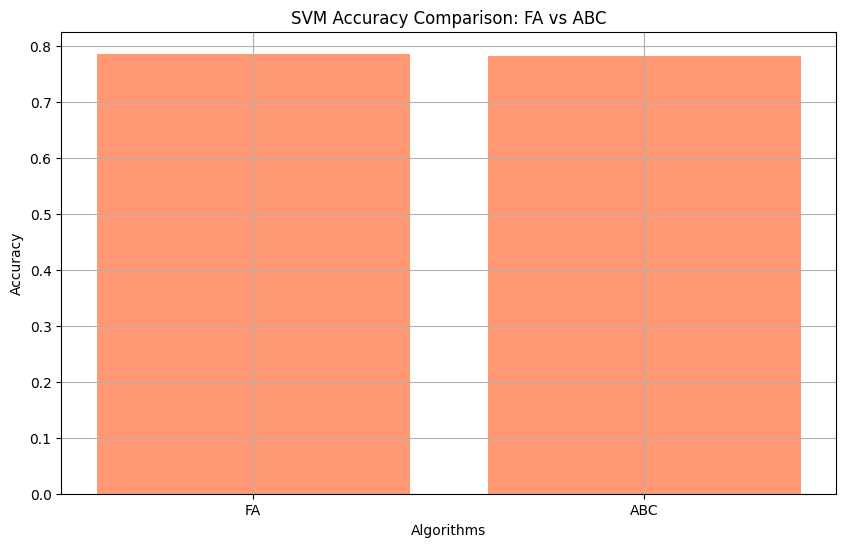

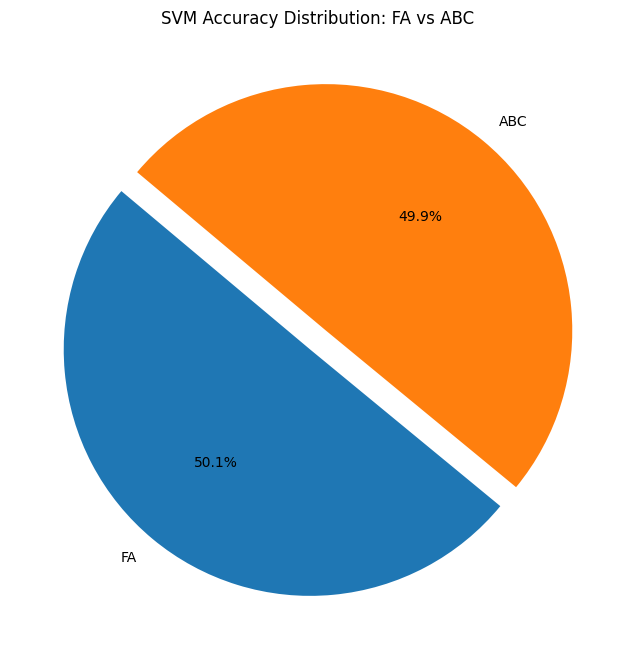

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC

# ----------------------------
# Mealpy imports
# ----------------------------
from mealpy.swarm_based import FA, ABC
from mealpy.utils.problem import FloatVar

warnings.filterwarnings("ignore")

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    df = pd.concat([amazon, imdb, yelp], axis=0)

    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# SVM Objective Function
# ----------------------------
def svm_objective_function(solution):
    C = solution[0]
    kernel_idx = int(solution[1])
    gamma = solution[2]

    kernel_options = ['linear', 'poly', 'rbf', 'sigmoid']
    kernel = kernel_options[kernel_idx % len(kernel_options)]  # wrap index safely

    try:
        model = SVC(C=C, kernel=kernel, gamma=gamma, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
        fitness = -np.mean(scores)  # negative because we are minimizing
    except:
        fitness = 1.0  # penalty for invalid params
    return fitness

# ----------------------------
# Problem Definition
# ----------------------------
svm_problem = {
    "bounds": [
        FloatVar(lb=0.1, ub=10, name="C"),             # Regularization strength
        FloatVar(lb=0, ub=3, name="kernel"),           # 0=linear,1=poly,2=rbf,3=sigmoid
        FloatVar(lb=0.0001, ub=1, name="gamma"),       # Kernel coefficient
    ],
    "minmax": "min",
    "obj_func": svm_objective_function,
}

# ----------------------------
# Only FA and ABC Algorithms
# ----------------------------
algorithms = {
    "FA": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10),
}

# ----------------------------
# Run Optimization
# ----------------------------
svm_results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing SVM using {name}...")
    best_agent = optimizer.solve(svm_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to positive accuracy

    kernel_options = ['linear', 'poly', 'rbf', 'sigmoid']
    kernel = kernel_options[int(best_solution[1]) % len(kernel_options)]

    best_params = {
        "C": round(best_solution[0], 3),
        "kernel": kernel,
        "gamma": round(best_solution[2], 4),
    }

    svm_results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Bar Chart of Accuracy
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(svm_results.keys(), svm_results.values(), color="coral", alpha=0.8)
plt.title("SVM Accuracy Comparison: FA vs ABC")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ----------------------------
# Pie Chart of Accuracy
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(
    svm_results.values(),
    labels=svm_results.keys(),
    autopct="%1.1f%%",
    startangle=140,
    explode=[0.05] * len(svm_results),
)
plt.title("SVM Accuracy Distribution: FA vs ABC")
plt.show()


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/10/10 09:49:31 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


⚙️ Using device: cpu
✅ Loading cached BERT embeddings from disk...
✅ BERT embeddings ready!

🚀 Optimizing SVM using PSO...


2025/10/10 09:50:35 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.9167468074161876, Global best: -0.9167468074161876, Runtime: 14.94145 seconds
2025/10/10 09:50:51 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.9167468074161876, Global best: -0.9167468074161876, Runtime: 16.45925 seconds
2025/10/10 09:51:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.9167468074161876, Global best: -0.9167468074161876, Runtime: 17.63741 seconds
2025/10/10 09:51:22 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.9167468074161876, Global best: -0.9167468074161876, Runtime: 13.05772 seconds
2025/10/10 09:51:39 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.9167468074161876, Global best: -0.9167468074161876, Runtime: 16.69669 seconds
2025/10/10 09:51:39 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: Bas

✅ PSO Accuracy: 0.9167
🏆 PSO Best Params: {'C': 0.967, 'kernel': 'rbf', 'gamma': 'scale'}


🚀 Optimizing SVM using GA...


2025/10/10 09:51:58 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.9144724253697035, Global best: -0.9144724253697035, Runtime: 8.94174 seconds
2025/10/10 09:52:09 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.9153825509359694, Global best: -0.9153825509359694, Runtime: 11.14398 seconds
2025/10/10 09:52:21 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.9153825509359694, Global best: -0.9153825509359694, Runtime: 12.06632 seconds
2025/10/10 09:52:34 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.9153825509359694, Global best: -0.9153825509359694, Runtime: 12.78685 seconds
2025/10/10 09:52:49 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.9153825509359694, Global best: -0.9153825509359694, Runtime: 15.73024 seconds
2025/10/10 09:52:49 PM, INFO, mealpy.swarm_based.BA.OriginalBA: Or

...

✅ Cuckoo Accuracy: 0.9177
🏆 Cuckoo Best Params: {'C': 9.543, 'kernel': 'rbf', 'gamma': 'auto'}


🚀 Optimizing SVM using Firefly...


2025/10/10 10:09:58 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.9167486711545486, Global best: -0.9167486711545486, Runtime: 252.94927 seconds
2025/10/10 10:15:25 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.9167486711545486, Global best: -0.9167486711545486, Runtime: 327.36800 seconds
2025/10/10 10:19:09 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.9172021808223807, Global best: -0.9172021808223807, Runtime: 223.92298 seconds
2025/10/10 10:24:39 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.9176575542285739, Global best: -0.9176575542285739, Runtime: 329.46569 seconds
2025/10/10 10:29:36 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.9176575542285739, Global best: -0.9176575542285739, Runtime: 296.93670 seconds
2025/10/10 10:29:36 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalA

✅ Firefly Accuracy: 0.9177
🏆 Firefly Best Params: {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale'}


🚀 Optimizing SVM using ABC...


2025/10/10 10:30:29 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.916292055256115, Global best: -0.916292055256115, Runtime: 22.91970 seconds
2025/10/10 10:30:47 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.916292055256115, Global best: -0.916292055256115, Runtime: 17.85724 seconds
2025/10/10 10:31:32 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.916292055256115, Global best: -0.916292055256115, Runtime: 45.06928 seconds
2025/10/10 10:32:42 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.916292055256115, Global best: -0.916292055256115, Runtime: 70.67262 seconds
2025/10/10 10:33:50 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.916292055256115, Global best: -0.916292055256115, Runtime: 67.72006 seconds


✅ ABC Accuracy: 0.9163
🏆 ABC Best Params: {'C': 1.421, 'kernel': 'rbf', 'gamma': 'scale'}



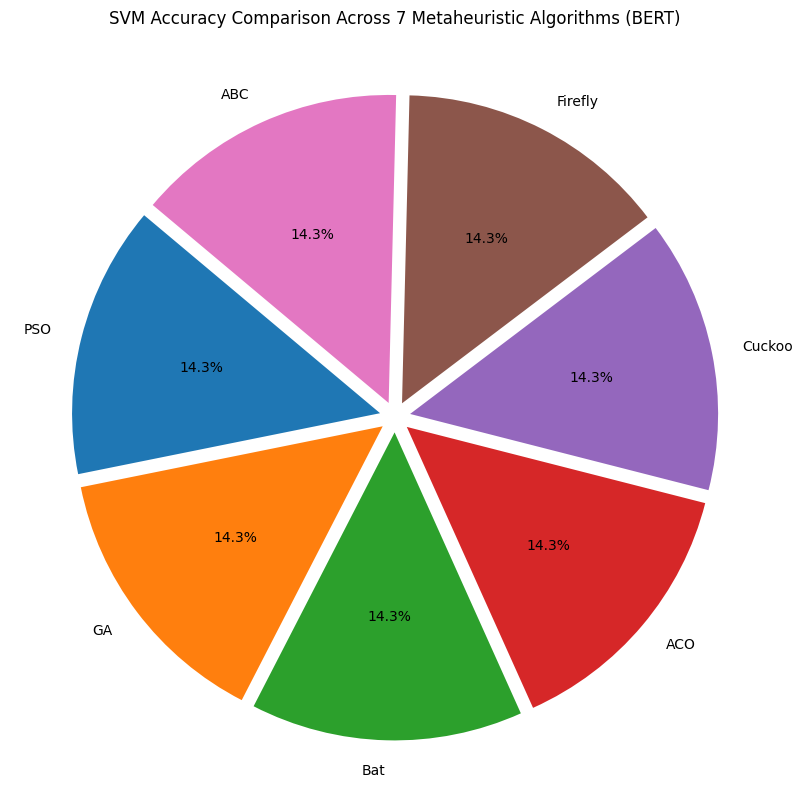

In [1]:
# ===============================================
#   BERT (bert-base-uncased) + Metaheuristic Optimization + SVM
#   (with caching + GPU + Visualization)
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel
import os

# ----------------------------
# Mealpy algorithm imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')


# ======================================================
# STEP 1: Load dataset + Use BERT for vectorization (with caching)
# ======================================================
def load_data_with_bert(cache_X="bert_base_embeddings.npy", cache_y="bert_base_labels.npy"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"⚙️ Using device: {device}")

    if os.path.exists(cache_X) and os.path.exists(cache_y):
        print("✅ Loading cached BERT embeddings from disk...")
        X = np.load(cache_X)
        y = np.load(cache_y)
    else:
        print("🔄 Generating new BERT embeddings (first run)...")

        # Load datasets
        amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
        imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
        yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
        df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)

        # Load BERT tokenizer and model
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        model = BertModel.from_pretrained('bert-base-uncased').to(device)

        def get_bert_embeddings(texts, batch_size=16):
            embeddings = []
            model.eval()
            with torch.no_grad():
                for i in range(0, len(texts), batch_size):
                    batch = texts[i:i+batch_size]
                    encoded = tokenizer(
                        batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt'
                    ).to(device)

                    outputs = model(**encoded)
                    batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()
                    embeddings.append(batch_embeddings)
            return torch.cat(embeddings).numpy()

        print("⚙️ Computing embeddings using BERT (this may take several minutes)...")
        X = get_bert_embeddings(df["text"].tolist())
        y = df["label"].values

        # Cache for reuse
        np.save(cache_X, X)
        np.save(cache_y, y)
        print(f"💾 Saved embeddings → {cache_X}, {cache_y}")

    print("✅ BERT embeddings ready!")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test


# ======================================================
# STEP 2: Load Data
# ======================================================
X_train, X_test, y_train, y_test = load_data_with_bert()


# ======================================================
# STEP 3: Objective Function for SVM
# ======================================================
def svm_objective_function(solution):
    C = float(solution[0])
    kernel_idx = int(solution[1])
    gamma_idx = int(solution[2])

    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    kernel = kernels[kernel_idx]

    gammas = ['scale', 'auto']
    gamma = gammas[gamma_idx]

    try:
        svm = SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            random_state=42
        )
        scores = cross_val_score(svm, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        fitness = -np.mean(scores)  # Mealpy minimizes, so we negate accuracy
    except Exception as e:
        print(f"⚠️ Error: {e}")
        fitness = 1.0
    return fitness


# ======================================================
# STEP 4: Define Optimization Problem
# ======================================================
svm_problem = {
    "bounds": [
        FloatVar(lb=0.1, ub=10, name="C"),         # Regularization parameter
        FloatVar(lb=0, ub=3, name="kernel"),       # 0=linear,1=poly,2=rbf,3=sigmoid
        FloatVar(lb=0, ub=1, name="gamma")         # 0=scale,1=auto
    ],
    "minmax": "min",
    "obj_func": svm_objective_function
}


# ======================================================
# STEP 5: Run All Metaheuristic Algorithms
# ======================================================
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}
best_params_dict = {}

for name, optimizer in algorithms.items():
    print(f"\n🚀 Optimizing SVM using {name}...")
    best_agent = optimizer.solve(svm_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to accuracy

    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    gammas = ['scale', 'auto']

    best_params = {
        'C': round(float(best_solution[0]), 3),
        'kernel': kernels[int(best_solution[1])],
        'gamma': gammas[int(best_solution[2])]
    }

    results[name] = best_fitness
    best_params_dict[name] = best_params

    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")


# ======================================================
# STEP 6: Visualization (Pie Chart)
# ======================================================
plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("SVM Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()
